# Figure 2 — PM2.5 and TPM Distribution

**Script file:** `Paper1_Figure2_pm25_tpm_distribution.ipynb`



**สิ่งที่ต้องเตรียมก่อนรัน:** ไฟล์ `บันทึกการตรวจวัดปริมาณฝุ่น.xlsx` (ข้อมูลภาคสนามต้นฉบับ 32 จุด)


In [1]:
# SCRIPT: Paper1_Figure2_pm25_tpm_distribution.ipynb
# SECTION: 0 - Setup
!pip install requests openpyxl  -q

In [2]:
import re, time, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import openpyxl
from datetime import datetime

plt.rcParams['figure.dpi'] = 120

## 1. อัปโหลดไฟล์ข้อมูลภาคสนามต้นฉบับ

In [3]:
# SCRIPT: Paper1_Figure2_pm25_tpm_distribution.ipynb
# SECTION: 1 - Load raw field data
from google.colab import files
uploaded = files.upload()  # เลือกไฟล์ "บันทึกการตรวจวัดปริมาณฝุ่น.xlsx"
RAW_XLSX = list(uploaded.keys())[0]
print("อัปโหลดไฟล์แล้ว:", RAW_XLSX)

Saving บันทึกการตรวจวัดปริมาณฝุ่น.xlsx to บันทึกการตรวจวัดปริมาณฝุ่น.xlsx
อัปโหลดไฟล์แล้ว: บันทึกการตรวจวัดปริมาณฝุ่น.xlsx


In [4]:
# SCRIPT: Paper1_Figure2_pm25_tpm_distribution.ipynb
# SECTION: 1 - Parse raw field data (name, address, link, PM2.5, TPM, date)
wb = openpyxl.load_workbook(RAW_XLSX, data_only=True)
ws = wb['Sheet1']

records = {}
order = []
for row in ws.iter_rows(min_row=3, max_row=1001, values_only=True):
    name = row[0]
    if not name:
        continue
    if name not in records:
        records[name] = {
            'name': name, 'url': row[1], 'address': row[2],
            'pm25': row[6], 'tpm': row[9], 'date': str(row[13]),
        }
        order.append(name)

sites_raw = [records[n] for n in order]
print(f"จำนวนจุดตรวจวัดทั้งหมด: {len(sites_raw)}")
assert len(sites_raw) == 32, "คาดว่าจะมี 32 จุด - ตรวจสอบไฟล์ต้นฉบับถ้าไม่ตรง"

จำนวนจุดตรวจวัดทั้งหมด: 32


## 2. Resolve พิกัด GPS จากลิงก์ Google Maps

ต้องรันบน Colab (ต้องมีอินเทอร์เน็ตเปิด) เพราะ short link (`goo.gl/maps/...`) ต้องไล่ตาม redirect

In [5]:
# SCRIPT: Paper1_Figure2_pm25_tpm_distribution.ipynb
# SECTION: 2 - Resolve GPS coordinates from Google Maps short links
PATTERNS = [
    re.compile(r"!3d(-?\d+\.\d+)!4d(-?\d+\.\d+)"),
    re.compile(r"@(-?\d+\.\d+),(-?\d+\.\d+)"),
    re.compile(r"[?&]q=(-?\d+\.\d+),(-?\d+\.\d+)"),
    re.compile(r"ll=(-?\d+\.\d+),(-?\d+\.\d+)"),
]

def extract_latlon(url_or_text):
    for pat in PATTERNS:
        m = pat.search(url_or_text)
        if m:
            return float(m.group(1)), float(m.group(2))
    return None, None

def resolve_link(short_url, timeout=15):
    try:
        r = requests.get(short_url, allow_redirects=True, timeout=timeout,
                          headers={'User-Agent': 'Mozilla/5.0'})
        lat, lon = extract_latlon(r.url)
        if lat is None:
            lat, lon = extract_latlon(r.text[:5000])
        return lat, lon
    except Exception:
        return None, None

for i, s in enumerate(sites_raw, 1):
    lat, lon = resolve_link(s['url'])
    s['lat'], s['lon'] = lat, lon
    print(f"[{i:02d}/32] {s['name']}: {'OK' if lat else 'FAILED - resolve manually'}")
    time.sleep(0.4)

missing = [s['name'] for s in sites_raw if s['lat'] is None]
if missing:
    print("\nจุดที่ resolve ไม่สำเร็จ (ต้องเติมพิกัดด้วยมือ):", missing)
else:
    print("\nพิกัดครบทั้ง 32 จุด")

[01/32] จุดตรวจวัดอากาศ-1: OK
[02/32] จุดตรวจวัดอากาศ-2: OK
[03/32] จุดตรวจวัดอากาศ-3: OK
[04/32] จุดตรวจวัดอากาศ-4: OK
[05/32] จุดตรวจวัดอากาศ-5: OK
[06/32] จุดตรวจวัดอากาศ-6: OK
[07/32] จุดตรวจวัดอากาศ-7: OK
[08/32] จุดตรวจวัดอากาศ-8: OK
[09/32] จุดตรวจวัดอากาศ-9: OK
[10/32] จุดตรวจวัดอากาศ-10: OK
[11/32] จุดตรวจวัดอากาศ-11: OK
[12/32] จุดตรวจวัดอากาศ-12: OK
[13/32] จุดตรวจวัดอากาศ-13: OK
[14/32] จุดตรวจวัดอากาศ-14: OK
[15/32] จุดตรวจวัดอากาศ-15: OK
[16/32] จุดตรวจวัดอากาศ-16: OK
[17/32] จุดตรวจวัดอากาศ-17: OK
[18/32] จุดตรวจวัดอากาศ-18: OK
[19/32] จุดตรวจวัดอากาศ-19: OK
[20/32] จุดตรวจวัดอากาศ-20: OK
[21/32] จุดตรวจวัดอากาศ-21: OK
[22/32] จุดตรวจวัดอากาศ-22: OK
[23/32] จุดตรวจวัดอากาศ-23: OK
[24/32] จุดตรวจวัดอากาศ-24: OK
[25/32] จุดตรวจวัดอากาศ-25: OK
[26/32] จุดตรวจวัดอากาศ-survey-0: OK
[27/32] จุดตรวจวัดอากาศ-survey-1: OK
[28/32] จุดตรวจวัดอากาศ-survey-2: OK
[29/32] จุดตรวจวัดอากาศ-survey-3: OK
[30/32] จุดตรวจวัดอากาศ-survey-4: OK
[31/32] จุดตรวจวัดอากาศ-survey-5: OK
[32/32] จุดต

In [6]:
# SCRIPT: Paper1_Figure2_pm25_tpm_distribution.ipynb
# SECTION: 2 - Manual coordinate override / field verification note
# sites_raw[<index>]['lat'], sites_raw[<index>]['lon'] = <lat>, <lon>

# ยืนยันภาคสนามแล้ว: Site 13 (Tab Kwang) อยู่ติดถนนมิตรภาพ ตรงข้าม TPI Polene
# พิกัดยืนยัน: 14 38 09.6 N, 101 06 55.3 E (คลาดเคลื่อนจากพิกัด resolve <300 m)

df = pd.DataFrame(sites_raw)
df['is_purposive'] = df['name'].str.contains('survey')
df[['name', 'address', 'lat', 'lon', 'pm25', 'tpm', 'date', 'is_purposive']]

,name,address,lat,lon,pm25,tpm,date,is_purposive
0,จุดตรวจวัดอากาศ-1,ตำบล ดอนดึง อำเภอ บ้านหมี่ ลพบุรี,15.132970,100.603782,14.62,62.32,5/6/66,False
1,จุดตรวจวัดอากาศ-2,ตำบล ดงมะรุม อำเภอ โคกสำโรง ลพบุรี,15.132317,100.860427,13.82,64.38,29/6/66,False
2,จุดตรวจวัดอากาศ-3,ตำบล ท่าดินดำ อำเภอชัยบาดาล ลพบุรี,15.131391,101.114891,20.54,79.06,13/6/66,False
3,จุดตรวจวัดอากาศ-4,ตำบล เขาน้อย อำเภอ ลำสนธิ ลพบุรี,15.130189,101.371070,12.82,33.15,13/6/66,False
4,จุดตรวจวัดอากาศ-5,ตำบล หินดาด อำเภอด่านขุนทด นครราชสีมา,15.128612,101.627133,22.62,96.48,13/6/66,False
5,จุดตรวจวัดอากาศ-6,ตำบล ท่าแค อำเภอเมืองลพบุรี ลพบุรี,14.884332,100.605227,27.29,94.75,29/6/66,False
6,จุดตรวจวัดอากาศ-7,ตำบล โคกตูม อำเภอเมืองลพบุรี ลพบุรี,14.884200,100.860728,10.98,133.49,5/6/66,False
7,จุดตรวจวัดอากาศ-8,ตำบล วังม่วง อำเภอ วังม่วง สระบุรี,14.883863,101.115129,7.93,57.85,5/6/23,False
8,จุดตรวจวัดอากาศ-9,ตำบล ลำพญากลาง อำเภอมวกเหล็ก สระบุรี,14.882626,101.370949,29.23,81.14,28/6/66,False
9,จุดตรวจวัดอากาศ-10,ตำบล ลาดบัวขาว อำเภอสีคิ้ว นครราชสีมา,14.882466,101.627188,14.23,71.31,25/6/66,False


## 3. สร้าง Figure 2

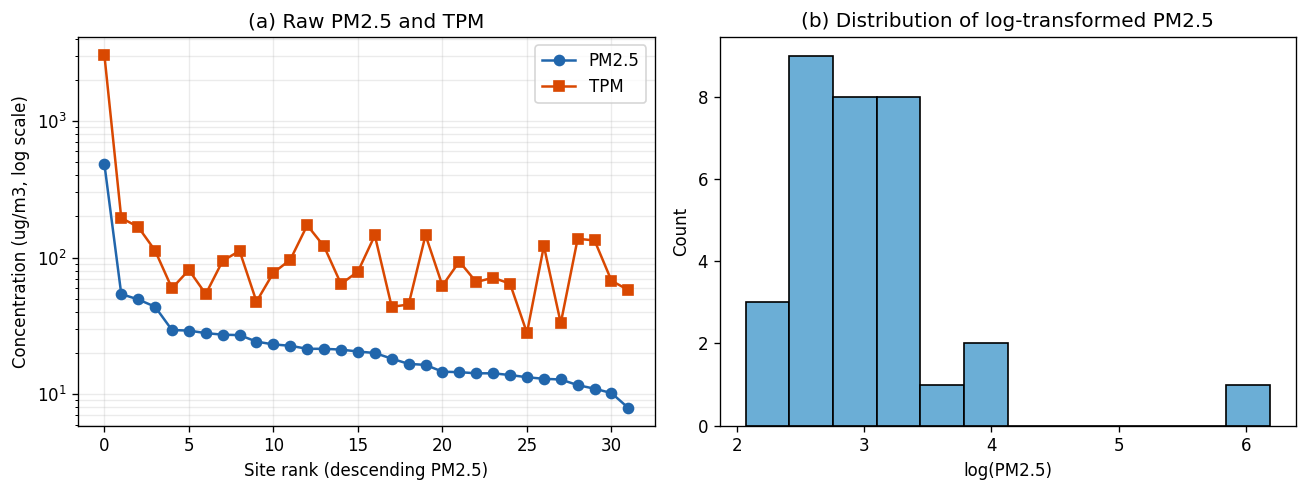

In [7]:
# SCRIPT: Paper1_Figure2_pm25_tpm_distribution.ipynb
# SECTION: 3 - FIGURE 2: (a) raw PM2.5 & TPM (log scale) (b) log-transformed PM2.5 histogram
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
idx_sorted = df['pm25'].sort_values(ascending=False).index
axes[0].plot(range(len(df)), df.loc[idx_sorted, 'pm25'], 'o-', color='#2166ac', label='PM2.5')
axes[0].plot(range(len(df)), df.loc[idx_sorted, 'tpm'], 's-', color='#d94801', label='TPM')
axes[0].set_yscale('log')
axes[0].set_xlabel('Site rank (descending PM2.5)'); axes[0].set_ylabel('Concentration (ug/m3, log scale)')
axes[0].set_title('(a) Raw PM2.5 and TPM'); axes[0].legend(); axes[0].grid(alpha=0.25, which='both')

axes[1].hist(np.log(df['pm25']), bins=12, color='#6baed6', edgecolor='black')
axes[1].set_xlabel('log(PM2.5)'); axes[1].set_ylabel('Count')
axes[1].set_title('(b) Distribution of log-transformed PM2.5')
plt.tight_layout()
plt.savefig('Figure2_pm25_tpm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## ดาวน์โหลดผลลัพธ์

In [8]:
# SCRIPT: Paper1_Figure2_pm25_tpm_distribution.ipynb
# SECTION: Download output
from google.colab import files as gfiles
for f in ['Figure2_pm25_tpm_distribution.png']:
    gfiles.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>